<a href="https://colab.research.google.com/github/tazeendev/spam-email-detector/blob/main/Email_Spam_Detection_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Email Detection using Machine Learning



1 Import all Required liabraries



In [3]:
# imports all liabraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from google.colab import files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,confusion_matrix, classification_report)
sns.set_style('whitegrid')
%matplotlib inline




[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


2 Load Dataset


In [4]:
# loaded dataset
uploaded=files.upload()
df = pd.read_csv('spam.csv', encoding='latin-1')
print(df.head(10))

Saving spam.csv to spam.csv
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   
5  spam  FreeMsg Hey there darling it's been 3 week's n...        NaN   
6   ham  Even my brother is not like to speak with me. ...        NaN   
7   ham  As per your request 'Melle Melle (Oru Minnamin...        NaN   
8  spam  WINNER!! As a valued network customer you have...        NaN   
9  spam  Had your mobile 11 months or more? U R entitle...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
5        NaN

In [31]:
print(df.info)

<bound method DataFrame.info of       Target                                               Text Unnamed: 2  \
0          0  Go until jurong point, crazy.. Available only ...        NaN   
1          0                      Ok lar... Joking wif u oni...        NaN   
2          1  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3          0  U dun say so early hor... U c already then say...        NaN   
4          0  Nah I don't think he goes to usf, he lives aro...        NaN   
...      ...                                                ...        ...   
5567       1  This is the 2nd time we have tried 2 contact u...        NaN   
5568       0              Will Ì_ b going to esplanade fr home?        NaN   
5569       0  Pity, * was in mood for that. So...any other s...        NaN   
5570       0  The guy did some bitching but I acted like i'd...        NaN   
5571       0                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0 

In [32]:
print(df.columns)

Index(['Target', 'Text', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [33]:
df.sample(5)

,Target,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4
3114,0,I wait 4 Ì_ inside da car park...,NaN,NaN,NaN
299,0,Need a coffee run tomo?Can't believe it's that...,NaN,NaN,NaN
2340,0,I will take care of financial problem.i will h...,NaN,NaN,NaN
659,1,88800 and 89034 are premium phone services cal...,NaN,NaN,NaN
2574,1,Your next amazing xxx PICSFREE1 video will be ...,NaN,NaN,NaN


In [34]:
df.shape

(5169, 5)

 3 Data Cleaning


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Target      5169 non-null   int64 
 1   Text        5169 non-null   object
 2   Unnamed: 2  43 non-null     object
 3   Unnamed: 3  10 non-null     object
 4   Unnamed: 4  5 non-null      object
dtypes: int64(1), object(4)
memory usage: 242.3+ KB


In [36]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'] ,inplace =True)

In [37]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [40]:
df.sample(5)

,Target,Text
2850,0,Are you going to wipro interview today?
5411,0,I ask if u meeting da ge tmr nite...
192,0,Hi :)finally i completed the course:)
5512,0,"Just making dinner, you ?"
60,0,Your gonna have to pick up a $1 burger for you...


In [41]:
df.rename(columns={ 'v1':'Target','v2' :'Text'}, inplace =True)

In [42]:
df.sample(10)

,Target,Text
1445,0,I am in a marriage function
4282,0,Science tells that chocolate will melt under t...
5152,0,Idk. I'm sitting here in a stop and shop parki...
2319,0,In which place do you want da.
5448,0,"aight we can pick some up, you open before ton..."
471,0,"How long has it been since you screamed, princ..."
4506,0,He neva grumble but i sad lor... Hee... Buy tm...
5046,0,Hmmm.still we dont have opener?
815,0,Where's my boytoy? I miss you ... What happened?
2039,0,Dont pack what you can buy at any store.like c...


In [43]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['Target']=encoder.fit_transform(df['Target'])
df.sample(10)


,Target,Text
5195,0,Darren was saying dat if u meeting da ge den w...
3537,0,We are pleased to inform that your application...
860,0,In work now. Going have in few min.
4641,1,You are being ripped off! Get your mobile cont...
1323,0,I thk 50 shd be ok he said plus minus 10.. Did...
4701,0,Anytime...
1777,1,Buy Space Invaders 4 a chance 2 win orig Arcad...
3713,0,"Oh, i will get paid. The most outstanding one ..."
1661,0,"You aren't coming home between class, right? I..."
1880,0,Just seeing your missed call my dear brother. ...


In [44]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [45]:
df.isnull().sum()

,0
Target,0
Text,0


In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
df=df.drop_duplicates(keep='first')

In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df['Target'].value_counts()

,count
Target,
0,4516
1,653


In [51]:
df.describe()

,Target
count,5169.000000
mean,0.126330
std,0.332253
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [52]:
df.shape

(5169, 2)

In [53]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


4. Exploratory Data Analysis (EDA)




In [55]:
# perform EDA on dataset
df['Text'].apply(len)

,Text
0,111
1,29
2,155
3,49
4,61
...,...
5567,161
5568,37
5569,57
5570,125


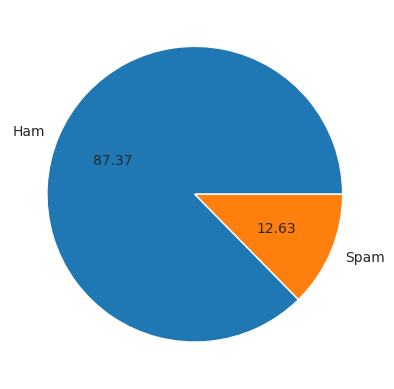

In [56]:
import matplotlib.pyplot as plt
plt.pie(df['Target'].value_counts(),labels=['Ham' , 'Spam'] , autopct='%0.2f')
plt.show()

In [61]:
from ast import Lambda
import nltk
nltk.download('punkt_tab')
# Character, Word, aur Sentence level tokens (Corrected to 'Text')
df['char_tokens'] = df['Text'].apply(lambda x: list(x))
df['word_tokens'] = df['Text'].apply(lambda x: nltk.word_tokenize(x))
df['sent_tokens'] = df['Text'].apply(lambda x: nltk.sent_tokenize(x))
# Features engineered for EDA
df['num_characters'] = df['Text'].apply(len)
df['num_words'] = df['Text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences'] = df['Text'].apply(lambda x: len(nltk.sent_tokenize(x)))

# Check new columns
df[['Text', 'num_characters', 'num_words', 'num_sentences']].head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Text,num_characters,num_words,num_sentences
0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,Ok lar... Joking wif u oni...,29,8,2
2,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,U dun say so early hor... U c already then say...,49,13,1
4,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [62]:
df.sample(10)

,Target,Text,char_tokens,word_tokens,sent_tokens,num_characters,num_words,num_sentences
5523,0,Going to join tomorrow.,"[G, o, i, n, g, , t, o, , j, o, i, n, , t, ...","[Going, to, join, tomorrow, .]",[Going to join tomorrow.],23,5,1
3032,0,"Aight, lemme know what's up","[A, i, g, h, t, ,, , l, e, m, m, e, , k, n, ...","[Aight, ,, lem, me, know, what, 's, up]","[Aight, lemme know what's up]",27,8,1
3485,0,"Yeah, probably earlier than that","[Y, e, a, h, ,, , p, r, o, b, a, b, l, y, , ...","[Yeah, ,, probably, earlier, than, that]","[Yeah, probably earlier than that]",32,6,1
914,0,"Call me da, i am waiting for your call.","[C, a, l, l, , m, e, , d, a, ,, , i, , a, ...","[Call, me, da, ,, i, am, waiting, for, your, c...","[Call me da, i am waiting for your call.]",39,11,1
1065,0,No my mum went 2 dentist.,"[N, o, , m, y, , m, u, m, , w, e, n, t, , ...","[No, my, mum, went, 2, dentist, .]",[No my mum went 2 dentist.],25,7,1
4364,0,Ujhhhhhhh computer shipped out with address to...,"[U, j, h, h, h, h, h, h, h, , c, o, m, p, u, ...","[Ujhhhhhhh, computer, shipped, out, with, addr...",[Ujhhhhhhh computer shipped out with address t...,87,16,3
2600,0,"As usual..iam fine, happy &amp; doing well..:)","[A, s, , u, s, u, a, l, ., ., i, a, m, , f, ...","[As, usual, .., iam, fine, ,, happy, &, amp, ;...","[As usual..iam fine, happy &amp; doing well..:)]",46,15,1
528,1,You will recieve your tone within the next 24h...,"[Y, o, u, , w, i, l, l, , r, e, c, i, e, v, ...","[You, will, recieve, your, tone, within, the, ...",[You will recieve your tone within the next 24...,111,21,2
4352,0,Fun fact: although you would think armand woul...,"[F, u, n, , f, a, c, t, :, , a, l, t, h, o, ...","[Fun, fact, :, although, you, would, think, ar...",[Fun fact: although you would think armand wou...,157,31,1
1280,0,Oh ho. Is this the first time u use these type...,"[O, h, , h, o, ., , I, s, , t, h, i, s, , ...","[Oh, ho, ., Is, this, the, first, time, u, use...","[Oh ho., Is this the first time u use these ty...",55,14,2


In [64]:
# Number of characters , Number of words ,Number of sentences
df['num_characters'] = df['Text'].apply(len)
df['num_words'] = df['Text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences'] = df['Text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df[['Text','num_characters','num_words','num_sentences']].sample(10)

,Text,num_characters,num_words,num_sentences
3290,I'm not smoking while people use \wylie smokes...,85,18,1
4505,When are you guys leaving?,26,6,1
1068,Someone U know has asked our dating service 2 ...,134,28,4
425,Ok. She'll be ok. I guess,25,8,2
2793,"The affidavit says &lt;#&gt; E Twiggs St, di...",142,44,2
2633,That's what I love to hear :V see you sundayis...,53,14,1
3690,"Sir, i am waiting for your call, once free ple...",58,15,1
4105,K then 2marrow are you coming to class.,39,9,1
5110,You have 1 new message. Please call 08715205273,47,9,2
232,"Sorry battery died, yeah I'm here",33,8,1


In [65]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [67]:
# for ham emails
df[df['Target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [69]:
#spam emails
df[df['Target']==1][['num_characters','num_words','num_sentences']].describe()



,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


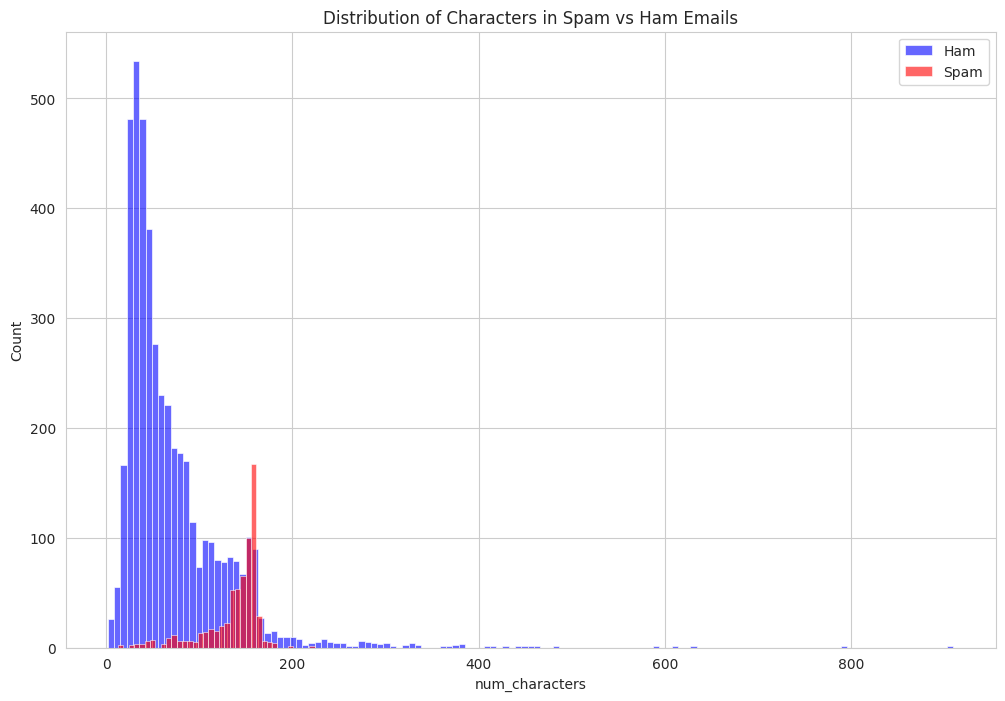

In [70]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['Target']==0]['num_characters'], color='blue', alpha=0.6, label='Ham')
sns.histplot(df[df['Target']==1]['num_characters'], color='red', alpha=0.6, label='Spam')
plt.legend()
plt.title("Distribution of Characters in Spam vs Ham Emails")
plt.show()

In [72]:
df['Target'].value_counts()

,count
Target,
0,4516
1,653


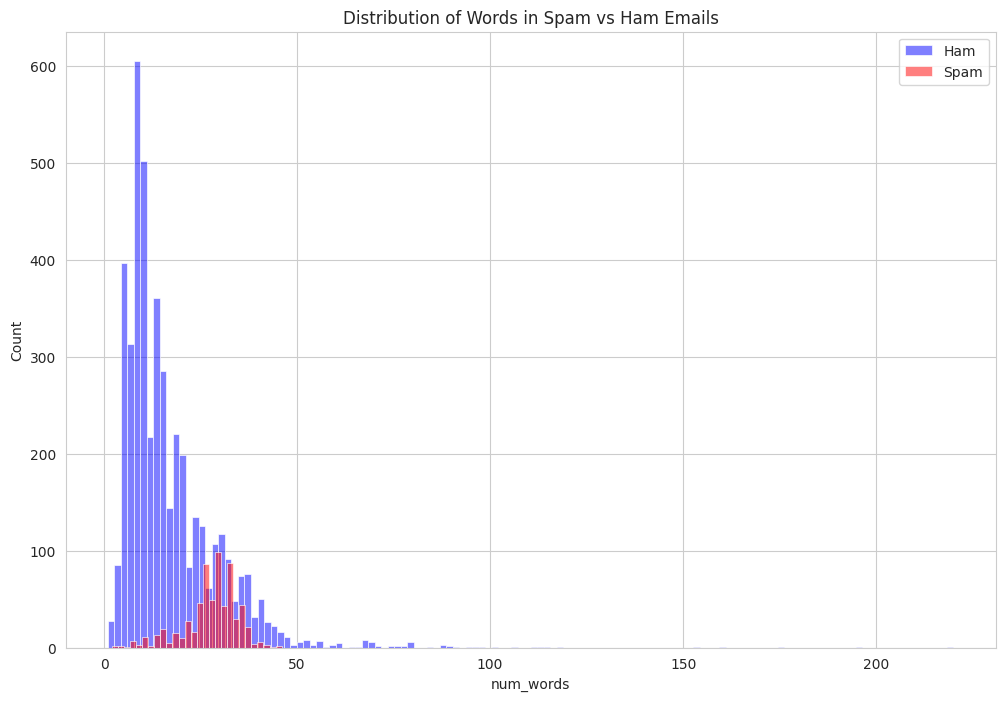

In [73]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['Target']==0]['num_words'], color='blue', alpha=0.5, label='Ham')
sns.histplot(df[df['Target']==1]['num_words'], color='red', alpha=0.5, label='Spam')
plt.legend()
plt.title("Distribution of Words in Spam vs Ham Emails")
plt.show()


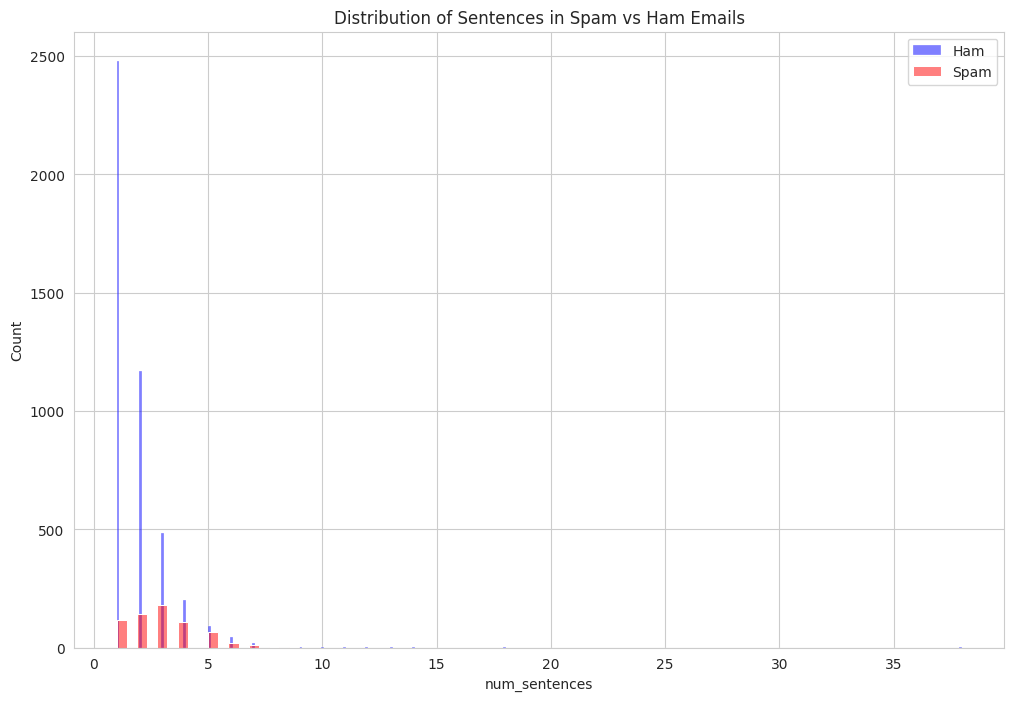

In [74]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['Target']==0]['num_sentences'], color='blue', alpha=0.5, label='Ham')
sns.histplot(df[df['Target']==1]['num_sentences'], color='red', alpha=0.5, label='Spam')
plt.legend()
plt.title("Distribution of Sentences in Spam vs Ham Emails")
plt.show()


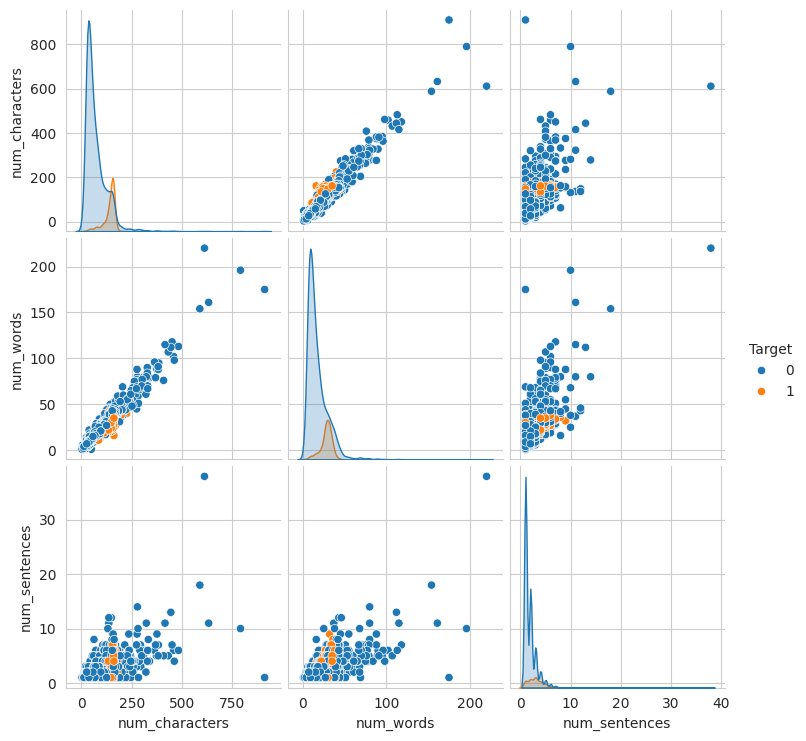

In [75]:
sns.pairplot(df,hue='Target')

In [76]:
numeric_df = df.select_dtypes(include=['int64','float64'])
corr_matrix = numeric_df.corr()
print(corr_matrix)

                  Target  num_characters  num_words  num_sentences
Target          1.000000        0.384717   0.262912       0.263939
num_characters  0.384717        1.000000   0.965760       0.624139
num_words       0.262912        0.965760   1.000000       0.679971
num_sentences   0.263939        0.624139   0.679971       1.000000


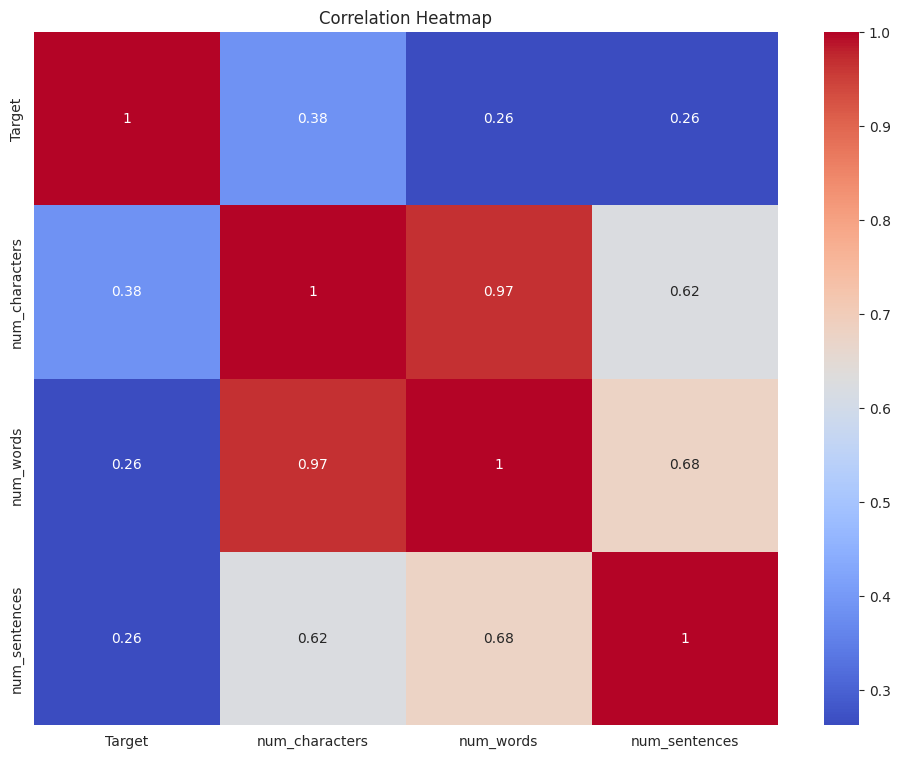

In [78]:
plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


5. Data Preprocessing

In [79]:
#data preprocessing
df['Text'][100]

'Okay name ur price as long as its legal! Wen can I pick them up? Y u ave x ams xx'

In [82]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_texts(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

# Apply on both Target & Text
df['clean_target'] = df['Target'].apply(clean_texts)
df['clean_text'] = df['Text'].apply(clean_texts)


In [81]:
df.head()

,Target,Text,char_tokens,word_tokens,sent_tokens,num_characters,num_words,num_sentences,clean_target,clean_text
0,0,"Go until jurong point, crazy.. Available only ...","[G, o, , u, n, t, i, l, , j, u, r, o, n, g, ...","[Go, until, jurong, point, ,, crazy, .., Avail...","[Go until jurong point, crazy.., Available onl...",111,24,2,,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,"[O, k, , l, a, r, ., ., ., , J, o, k, i, n, ...","[Ok, lar, ..., Joking, wif, u, oni, ...]","[Ok lar..., Joking wif u oni...]",29,8,2,,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,"[F, r, e, e, , e, n, t, r, y, , i, n, , 2, ...","[Free, entry, in, 2, a, wkly, comp, to, win, F...",[Free entry in 2 a wkly comp to win FA Cup fin...,155,37,2,,free entry wkly comp win fa cup final tkts st ...
3,0,U dun say so early hor... U c already then say...,"[U, , d, u, n, , s, a, y, , s, o, , e, a, ...","[U, dun, say, so, early, hor, ..., U, c, alrea...",[U dun say so early hor... U c already then sa...,49,13,1,,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...","[N, a, h, , I, , d, o, n, ', t, , t, h, i, ...","[Nah, I, do, n't, think, he, goes, to, usf, ,,...","[Nah I don't think he goes to usf, he lives ar...",61,15,1,,nah dont think go usf life around though


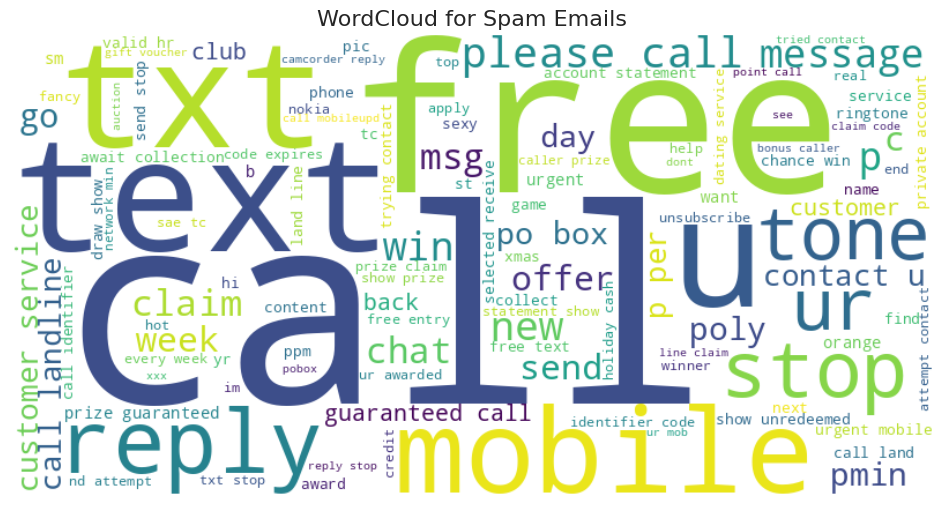

In [85]:
from wordcloud import WordCloud
# WordCloud object
wc = WordCloud(
    width=800,
    height=400,
    min_font_size=10,
    background_color='white',
    colormap='viridis'
)
spam_text = df[df['Target'] == 1]['clean_text'].str.cat(sep=" ")
spam_wc = wc.generate(spam_text)
# Plot
plt.figure(figsize=(12,6))
plt.imshow(spam_wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud for Spam Emails", fontsize=16)
plt.show()


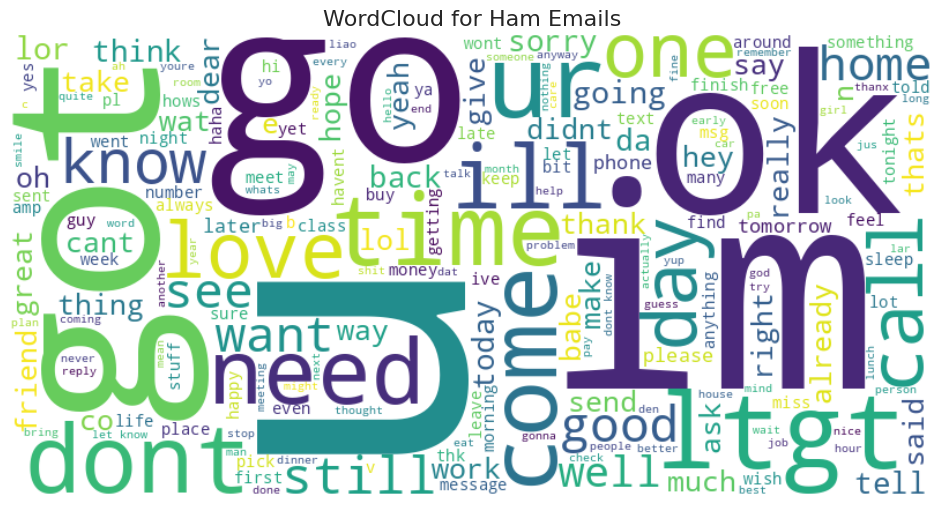

In [86]:
from wordcloud import WordCloud
# WordCloud object
wc = WordCloud(
    width=800,
    height=400,
    min_font_size=10,
    background_color='white',
    colormap='viridis'
)
spam_text = df[df['Target'] == 0]['clean_text'].str.cat(sep=" ")
spam_wc = wc.generate(spam_text)
# Plot
plt.figure(figsize=(12,6))
plt.imshow(spam_wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud for Ham Emails", fontsize=16)
plt.show()

In [113]:
spam_value = []
for mess in df[df['Target'] == 1][['clean_text', 'clean_target']].values.tolist():
    combined = " ".join([str(m) for m in mess if pd.notnull(m)])
    for word in combined.split():
        spam_value.append(word)

print(spam_value[:50])


['free', 'entry', 'wkly', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', 'st', 'may', 'text', 'fa', 'receive', 'entry', 'questionstd', 'txt', 'ratetcs', 'apply', 'over', 'freemsg', 'hey', 'darling', 'week', 'word', 'back', 'id', 'like', 'fun', 'still', 'tb', 'ok', 'xxx', 'std', 'chgs', 'send', 'rcv', 'winner', 'valued', 'network', 'customer', 'selected', 'receivea', 'prize', 'reward', 'claim', 'call', 'claim', 'code', 'kl']


In [114]:
len(spam_value)

9120

In [116]:
len(ham_value)

35956

In [115]:
ham_value = []
for mess in df[df['Target'] == 0][['clean_text', 'clean_target']].values.tolist():
    combined = " ".join([str(m) for m in mess if pd.notnull(m)])
    for word in combined.split():
        ham_value.append(word)
print(ham_value[:50])


['go', 'jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amore', 'wat', 'ok', 'lar', 'joking', 'wif', 'u', 'oni', 'u', 'dun', 'say', 'early', 'hor', 'u', 'c', 'already', 'say', 'nah', 'dont', 'think', 'go', 'usf', 'life', 'around', 'though', 'even', 'brother', 'like', 'speak', 'treat', 'like', 'aid', 'patent', 'per', 'request', 'melle']


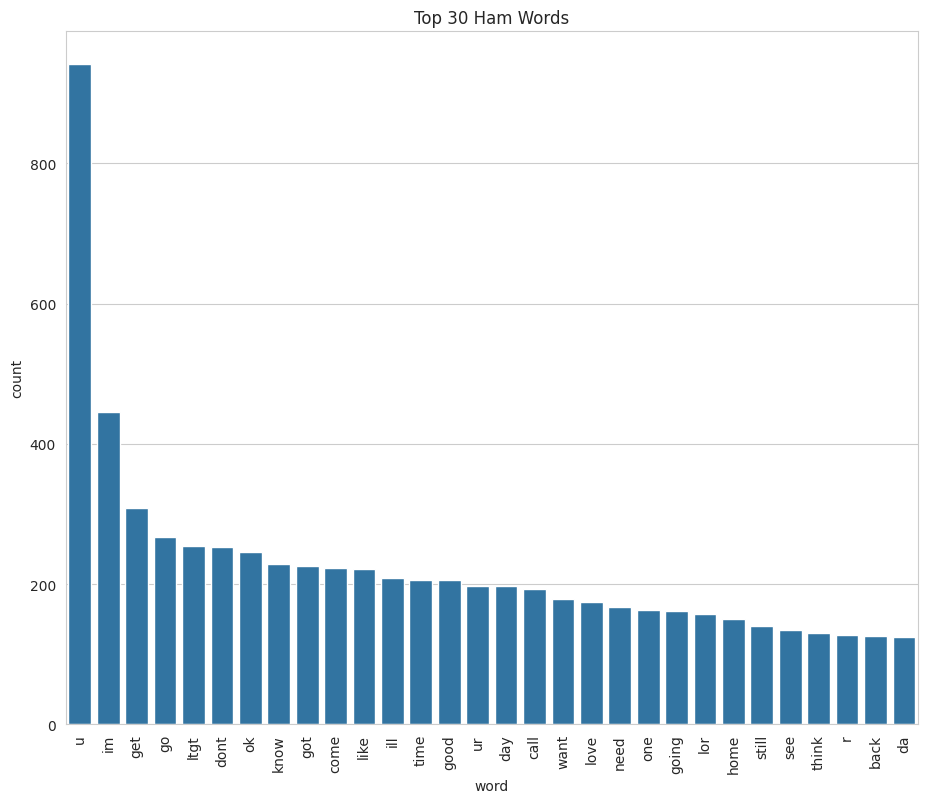

In [93]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
ham_counter = Counter(ham_value).most_common(30)
df_ham = pd.DataFrame(ham_counter, columns=["word", "count"])
# Plot
plt.figure(figsize=(11,9))
sns.barplot(x="word", y="count", data=df_ham)
plt.xticks(rotation=90)
plt.title("Top 30 Ham Words")
plt.show()

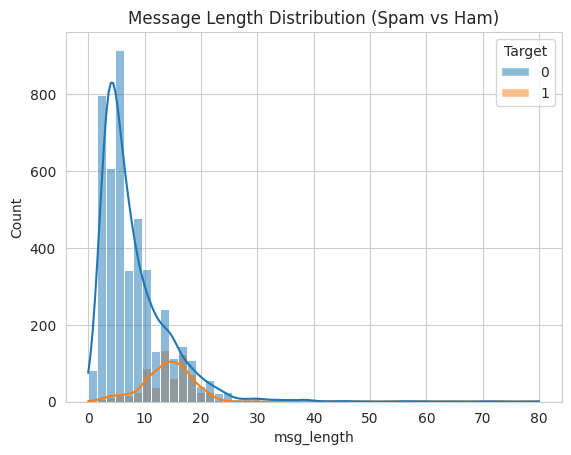

In [95]:
df["msg_length"] = df["clean_text"].apply(lambda x: len(str(x).split()))
sns.histplot(data=df, x="msg_length", hue="Target", bins=50, kde=True)
plt.title("Message Length Distribution (Spam vs Ham)")
plt.show()


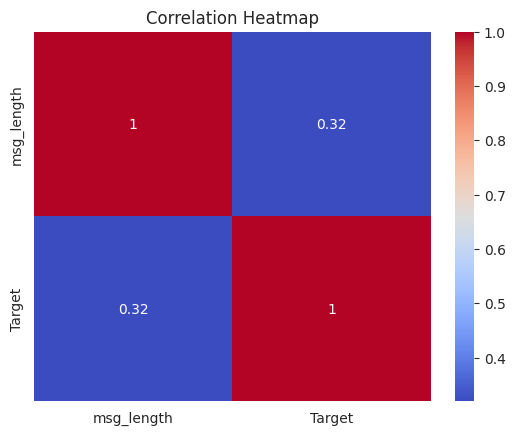

In [97]:
sns.heatmap(df[["msg_length", "Target"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

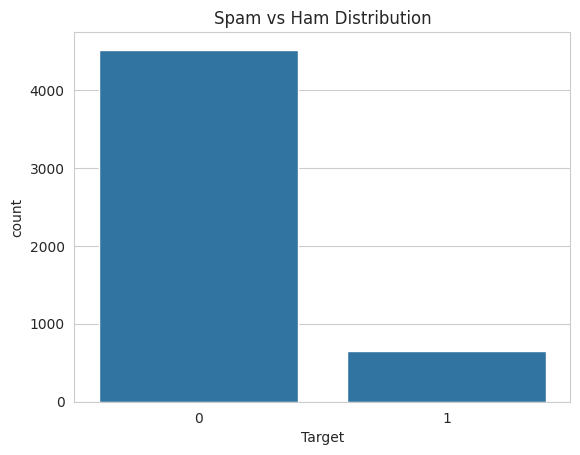

In [99]:
sns.countplot(x="Target", data=df)
plt.title("Spam vs Ham Distribution")
plt.show()


In [100]:
df.sample(20)

,Target,Text,char_tokens,word_tokens,sent_tokens,num_characters,num_words,num_sentences,clean_target,clean_text,msg_length
2342,1,Double your mins & txts on Orange or 1/2 price...,"[D, o, u, b, l, e, , y, o, u, r, , m, i, n, ...","[Double, your, mins, &, txts, on, Orange, or, ...",[Double your mins & txts on Orange or 1/2 pric...,160,24,1,,double min txts orange price linerental motoro...,14
4767,0,I'm not sure if its still available though,"[I, ', m, , n, o, t, , s, u, r, e, , i, f, ...","[I, 'm, not, sure, if, its, still, available, ...",[I'm not sure if its still available though],42,9,1,,im sure still available though,5
1705,0,Yun ah.now Ì_ wkg where?btw if Ì_ go nus sc. Ì...,"[Y, u, n, , a, h, ., n, o, w, , Ì, _, , w, ...","[Yun, ah.now, Ì_, wkg, where, ?, btw, if, Ì_, ...","[Yun ah.now Ì_ wkg where?btw if Ì_ go nus sc.,...",71,19,2,,yun ahnow wkg wherebtw go nu sc wana specialis...,10
3952,1,Refused a loan? Secured or Unsecured? Can't ge...,"[R, e, f, u, s, e, d, , a, , l, o, a, n, ?, ...","[Refused, a, loan, ?, Secured, or, Unsecured, ...","[Refused a loan?, Secured or Unsecured?, Can't...",114,28,4,,refused loan secured unsecured cant get credit...,12
847,0,I am in office:)whats the matter..msg me now.i...,"[I, , a, m, , i, n, , o, f, f, i, c, e, :, ...","[I, am, in, office, :, ), whats, the, matter, ...",[I am in office:)whats the matter..msg me now....,72,21,1,,officewhats mattermsg nowi call break,5
791,0,All e best 4 ur driving tmr :-),"[A, l, l, , e, , b, e, s, t, , 4, , u, r, ...","[All, e, best, 4, ur, driving, tmr, :, -, )]",[All e best 4 ur driving tmr :-)],31,10,1,,e best ur driving tmr,5
2706,0,S now only i took tablets . Reaction morning o...,"[S, , n, o, w, , o, n, l, y, , i, , t, o, ...","[S, now, only, i, took, tablets, ., Reaction, ...","[S now only i took tablets ., Reaction morning...",50,11,2,,took tablet reaction morning,4
747,1,U are subscribed to the best Mobile Content Se...,"[U, , a, r, e, , s, u, b, s, c, r, i, b, e, ...","[U, are, subscribed, to, the, best, Mobile, Co...",[U are subscribed to the best Mobile Content S...,132,26,2,,u subscribed best mobile content service uk pe...,12
218,0,I have to take exam with march 3,"[I, , h, a, v, e, , t, o, , t, a, k, e, , ...","[I, have, to, take, exam, with, march, 3]",[I have to take exam with march 3],32,8,1,,take exam march,3
1511,0,Oops sorry. Just to check that you don't mind ...,"[O, o, p, s, , s, o, r, r, y, ., , J, u, s, ...","[Oops, sorry, ., Just, to, check, that, you, d...","[Oops sorry., Just to check that you don't min...",110,26,3,,oops sorry check dont mind picking tomo half e...,12


6. Train-Test Split

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['Target'],
    test_size=0.2,
    random_state=42,
    stratify=df['Target']
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4135
Testing samples: 1034


7. Feature Extraction — TF-IDF

In [118]:
tfidf = TfidfVectorizer(stop_words='english', max_features=3000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF feature matrix shape (train):", X_train_tfidf.shape)

TF-IDF feature matrix shape (train): (4135, 3000)


8. Model Training :

 We train and compare four classification algorithms:
- Multinomial Naive Bayes : a classic, fast baseline for text classification
- Logistic Regression : a strong linear baseline
- Linear SVM : often performs best on high-dimensional sparse text data
- Random Forest : an ensemble tree-based model


In [107]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1})
    print(f"{name}: Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | F1={f1:.4f}")

Naive Bayes: Accuracy=0.9720 | Precision=0.9904 | Recall=0.7863 | F1=0.8766
Logistic Regression: Accuracy=0.9526 | Precision=0.9881 | Recall=0.6336 | F1=0.7721
Linear SVM: Accuracy=0.9807 | Precision=0.9912 | Recall=0.8550 | F1=0.9180
Random Forest: Accuracy=0.9720 | Precision=0.9636 | Recall=0.8092 | F1=0.8797


9. Model Comparison

In [108]:
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,0.980658,0.991150,0.854962,0.918033
1,Random Forest,0.971954,0.963636,0.809160,0.879668
2,Naive Bayes,0.971954,0.990385,0.786260,0.876596
3,Logistic Regression,0.952611,0.988095,0.633588,0.772093


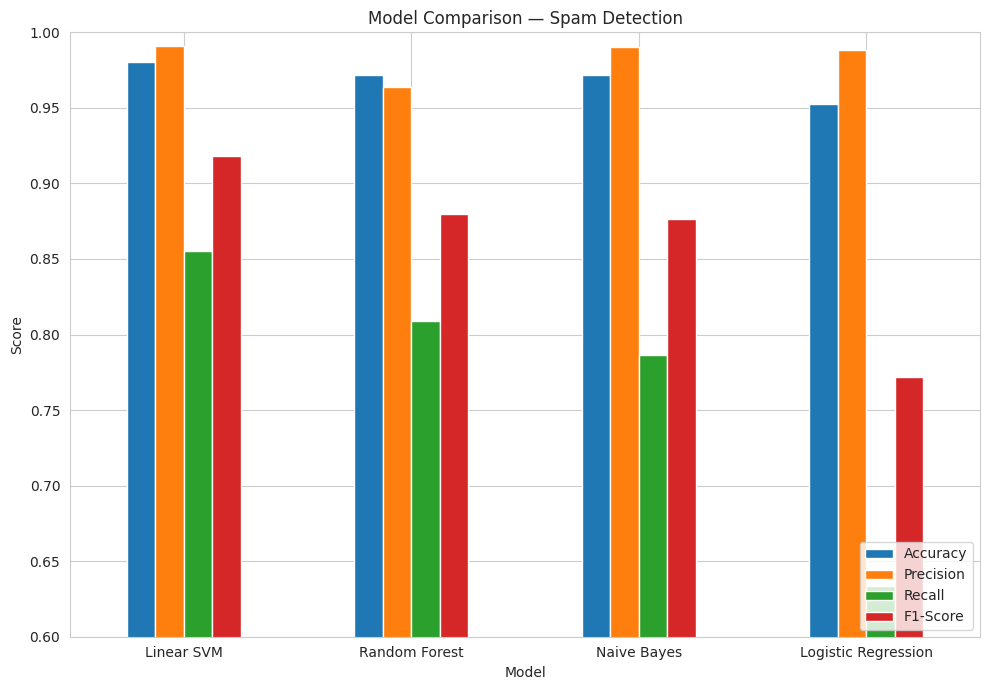

In [110]:
# Visualize comparison
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind='bar', figsize=(10,7)
)
plt.title("Model Comparison — Spam Detection")
plt.ylabel("Score")
plt.ylim(0.6, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Best model: Linear SVM


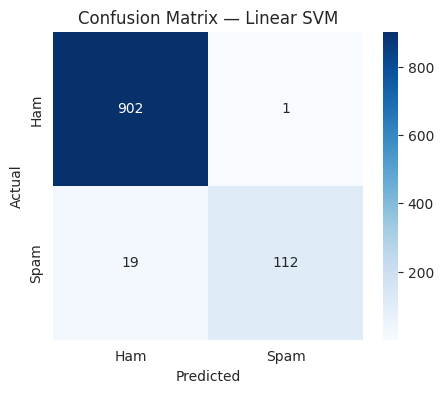

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.99      0.85      0.92       131

    accuracy                           0.98      1034
   macro avg       0.99      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [111]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print("Best model:", best_model_name)

preds = best_model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, preds, target_names=['Ham', 'Spam']))


In [112]:
def predict_message(message, model=best_model, vectorizer=tfidf):
    cleaned = clean_text(message)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return "SPAM" if pred == 1 else "HAM (Not Spam)"

test_messages = [
    "Congratulations! You've won a free iPhone. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been suspended. Verify your details immediately.",
    "Can you send me the report before end of day?"
]

for msg in test_messages:
    print(f"Message: {msg}\nPrediction: {predict_message(msg)}\n")


Message: Congratulations! You've won a free iPhone. Click here to claim now!
Prediction: SPAM

Message: Hey, are we still meeting for lunch tomorrow?
Prediction: HAM (Not Spam)

Message: URGENT: Your account has been suspended. Verify your details immediately.
Prediction: SPAM

Message: Can you send me the report before end of day?
Prediction: HAM (Not Spam)

